## Alphabet Inc. (Google) (GOOG) — Technical Analysis

### Overview
This notebook performs technical analysis on **Alphabet Inc. (GOOG)** stock price data using industry-standard indicators. The analysis covers moving averages, Bollinger Bands, momentum indicators, volatility metrics, time series decomposition, and stationarity analysis.

### Objectives
- Load and validate GOOG historical stock price data
- Compute technical indicators using TA-Lib and PyNance
- Visualize price trends with overlaid technical indicators
- Analyze momentum and volatility patterns
- Compute quantitative performance metrics

### Dataset
The analysis uses historical GOOG stock price data containing Open, High, Low, Close, and Volume (OHLCV) data.

### Understanding Stock Market Data
Before diving into analysis, let's define the standard columns in our dataset:

- **Open:** The price at the start of the trading day
- **High:** The maximum price reached during the day
- **Low:** The minimum price reached during the day
- **Close:** The final price when the market closed — primary price for technical indicators
- **Volume:** The total number of shares traded during the period

## 1. Environment Setup & Library Imports

In [1]:
# Fix PyNance compatibility with modern pandas_datareader
import pandas.util._decorators as _dec

def _patched_deprecate_kwarg(*args, **kwargs):
    if len(args) == 2 and isinstance(args[0], str):
        return _original_deprecate_kwarg(FutureWarning, args[0], args[1], **kwargs)
    return _original_deprecate_kwarg(*args, **kwargs)

if not hasattr(_dec, '_original_deprecate_kwarg'):
    _original_deprecate_kwarg = _dec.deprecate_kwarg
    _dec.deprecate_kwarg = _patched_deprecate_kwarg

import pynance as pn
print("✅ PyNance imported successfully!")

✅ PyNance imported successfully!


In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import talib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_stock_data
from src.analysis import (
    compute_sma,
    compute_ema,
    compute_rsi,
    compute_macd,
    compute_bollinger_bands,
    get_daily_return,
    check_stationarity
)

# Global plot settings
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 7]
plt.rcParams['figure.dpi'] = 100

print(f"TA-Lib version : {talib.__version__}")
print("✅ All libraries imported successfully!")

TA-Lib version : 0.6.8
✅ All libraries imported successfully!


## 2. Load & Clean Stock Price Data

We load the GOOG historical stock price dataset using our modular `load_stock_data()` function from `src/data_loader.py`. This enforces correct data types, sorts by date, and handles missing values automatically.

In [3]:
goog = load_stock_data('../data/raw/GOOG.csv')

print(f"Dataset Shape: {goog.shape}")
print(f"\nColumn Names: {goog.columns.tolist()}")
print(f"\nDate range: {goog['Date'].min().date()} to {goog['Date'].max().date()}")
print(f"Total trading days: {len(goog)}")
goog.head()

✅ Loaded 3774 rows. No missing values.
Dataset Shape: (3774, 6)

Column Names: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']

Date range: 2009-01-02 to 2023-12-29
Total trading days: 3774


,Date,Close,High,Low,Open,Volume
0,2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322.0
1,2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007.0
2,2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329.0
3,2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860.0
4,2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852.0


## 3. Moving Averages (SMA & EMA)

Moving averages smooth out price data to identify trends:
- **SMA (Simple Moving Average)** — equal weight to all periods
- **EMA (Exponential Moving Average)** — more weight to recent prices

**Interpretation:**
- **Golden Cross:** Short-term MA crosses above long-term MA → bullish signal
- **Death Cross:** Short-term MA crosses below long-term MA → bearish signal

In [4]:
goog['SMA_20'] = compute_sma(goog['Close'], 20)
goog['SMA_50'] = compute_sma(goog['Close'], 50)
goog['EMA_20'] = compute_ema(goog['Close'], 20)
goog['EMA_50'] = compute_ema(goog['Close'], 50)

print("✅ Moving averages computed successfully!")
print(goog[['Date', 'Close', 'SMA_20', 'SMA_50', 'EMA_20', 'EMA_50']].tail(10))

✅ Moving averages computed successfully!
           Date       Close      SMA_20      SMA_50      EMA_20      EMA_50
3764 2023-12-15  132.930344  134.624729  133.913792  133.658729  133.376533
3765 2023-12-18  136.257538  134.637142  133.883201  133.906234  133.489514
3766 2023-12-19  137.161362  134.646081  133.855391  134.216247  133.633508
3767 2023-12-20  138.710785  134.697729  133.864529  134.644298  133.832617
3768 2023-12-21  140.836227  134.786124  133.866516  135.234005  134.107268
3769 2023-12-22  141.750000  135.009596  133.914786  135.854576  134.406983
3770 2023-12-26  141.849304  135.246477  133.999010  136.425503  134.698839
3771 2023-12-27  140.478683  135.386520  134.017881  136.811520  134.925499
3772 2023-12-28  140.319748  135.628861  134.023641  137.145637  135.137038
3773 2023-12-29  139.972137  135.976979  134.056417  137.414827  135.326650


### 3.1 Moving Averages Visualization

The chart below shows GOOG closing prices overlaid with 20-day and 50-day SMA and EMA. When the short-term average crosses above the long-term average it signals a potential **buy opportunity**, and vice versa.

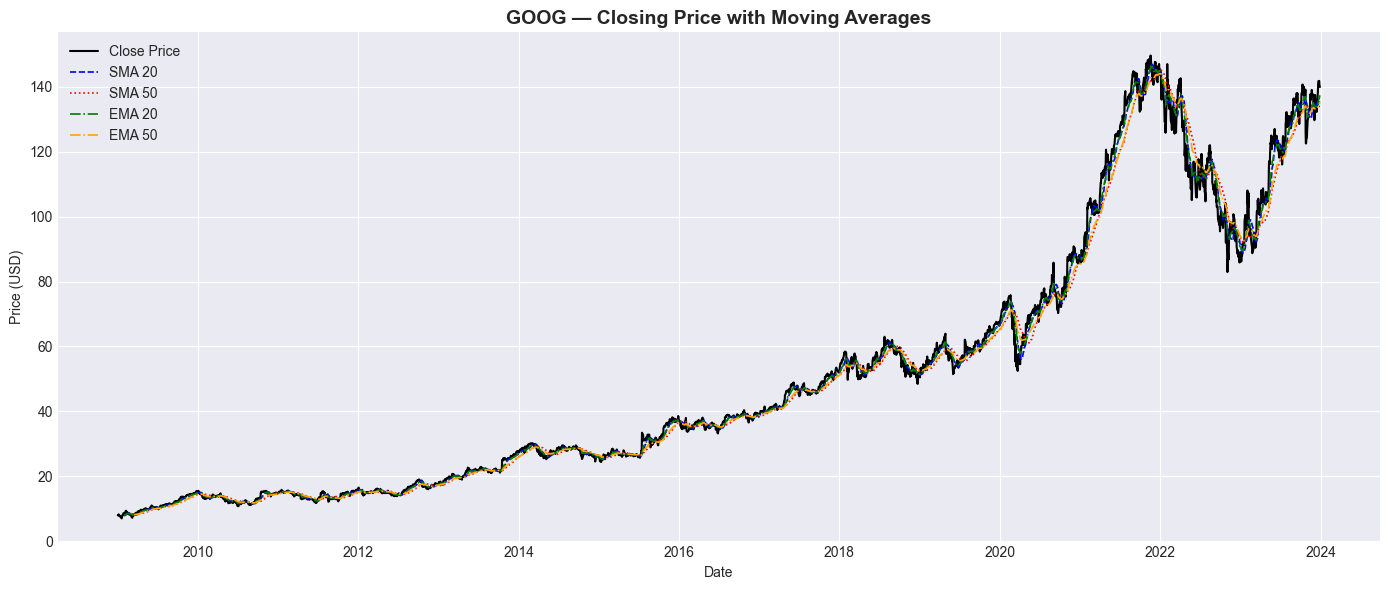

✅ Moving averages plot rendered!


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(goog['Date'], goog['Close'], label='Close Price', color='black', linewidth=1.5)
ax.plot(goog['Date'], goog['SMA_20'], label='SMA 20', color='blue', linewidth=1.2, linestyle='--')
ax.plot(goog['Date'], goog['SMA_50'], label='SMA 50', color='red', linewidth=1.2, linestyle=':')
ax.plot(goog['Date'], goog['EMA_20'], label='EMA 20', color='green', linewidth=1.2, linestyle='-.')
ax.plot(goog['Date'], goog['EMA_50'], label='EMA 50', color='orange', linewidth=1.2, linestyle='-.')

ax.set_title('GOOG — Closing Price with Moving Averages', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Moving averages plot rendered!")

## 4. Bollinger Bands

Bollinger Bands consist of:
- **Middle Band** — 20-day SMA
- **Upper Band** — Middle Band + 2 standard deviations
- **Lower Band** — Middle Band - 2 standard deviations

Price touching the upper band suggests **overbought** conditions while touching the lower band suggests **oversold** conditions.

In [6]:
goog['BB_Upper'], goog['BB_Middle'], goog['BB_Lower'] = compute_bollinger_bands(
    goog['Close'])

print("✅ Bollinger Bands computed successfully!")
print(goog[['Date', 'Close', 'BB_Upper', 'BB_Middle', 'BB_Lower']].tail(10))

✅ Bollinger Bands computed successfully!
           Date       Close    BB_Upper   BB_Middle    BB_Lower
3764 2023-12-15  132.930344  139.958304  134.624729  129.291155
3765 2023-12-18  136.257538  139.984685  134.637142  129.289599
3766 2023-12-19  137.161362  140.009849  134.646081  129.282312
3767 2023-12-20  138.710785  140.195493  134.697729  129.199965
3768 2023-12-21  140.836227  140.609353  134.786124  128.962896
3769 2023-12-22  141.750000  141.503046  135.009596  128.516146
3770 2023-12-26  141.849304  142.346688  135.246477  128.146265
3771 2023-12-27  140.478683  142.777559  135.386520  127.995480
3772 2023-12-28  140.319748  143.326809  135.628861  127.930914
3773 2023-12-29  139.972137  143.798395  135.976979  128.155563


### 4.1 Bollinger Bands Visualization

The shaded region between the upper and lower bands represents the expected price range. Prices outside this range signal potential reversals.

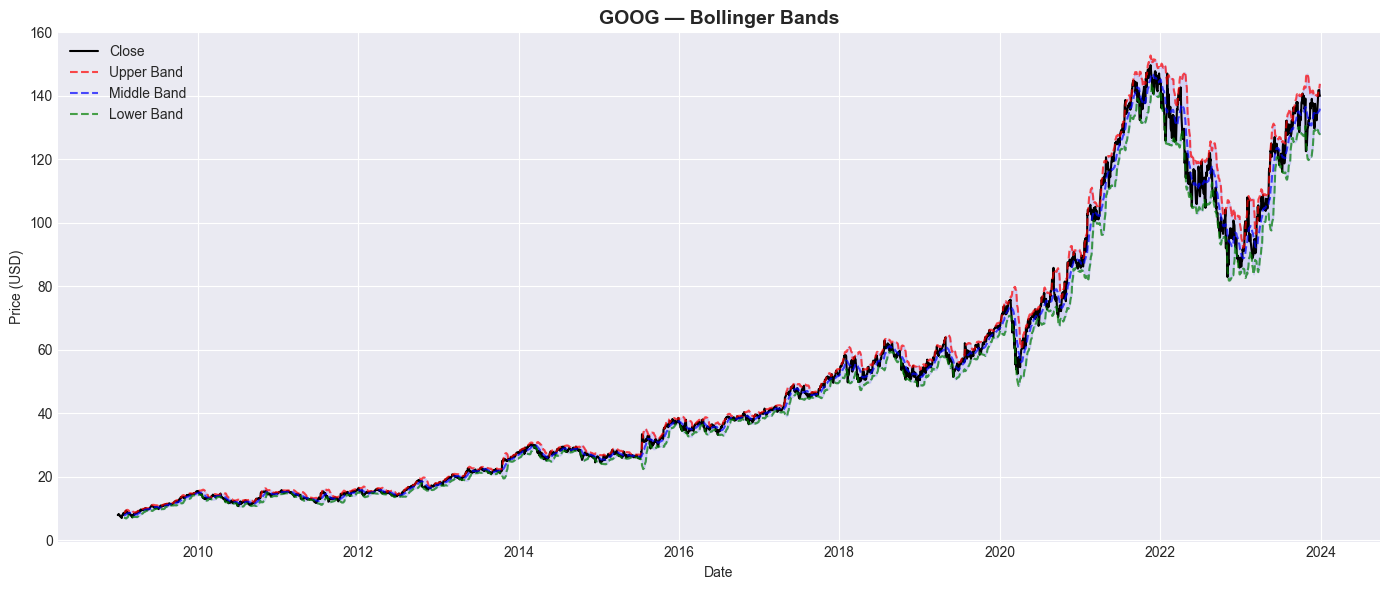

✅ Bollinger Bands plot rendered!


In [7]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(goog['Date'], goog['Close'], label='Close', color='black', linewidth=1.5)
ax.plot(goog['Date'], goog['BB_Upper'], label='Upper Band', color='red',
        linestyle='--', alpha=0.7)
ax.plot(goog['Date'], goog['BB_Middle'], label='Middle Band', color='blue',
        linestyle='--', alpha=0.7)
ax.plot(goog['Date'], goog['BB_Lower'], label='Lower Band', color='green',
        linestyle='--', alpha=0.7)
ax.fill_between(goog['Date'], goog['BB_Upper'], goog['BB_Lower'],
                alpha=0.1, color='blue')

ax.set_title('GOOG — Bollinger Bands', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
plt.tight_layout()
plt.show()
print("✅ Bollinger Bands plot rendered!")

## 5. RSI (Relative Strength Index)

RSI is a **momentum oscillator** that measures the speed and change of price movements:
- **RSI >= 70** — Overbought: potential sell signal
- **RSI <= 30** — Oversold: potential buy signal
- **RSI = 50** — Neutral momentum

We use the standard 14-day period.

In [8]:
goog['RSI'] = compute_rsi(goog['Close'])

print("✅ RSI computed successfully!")
print(goog[['Date', 'Close', 'RSI']].tail(10))

✅ RSI computed successfully!
           Date       Close        RSI
3764 2023-12-15  132.930344  48.205282
3765 2023-12-18  136.257538  55.322365
3766 2023-12-19  137.161362  57.048922
3767 2023-12-20  138.710785  59.909189
3768 2023-12-21  140.836227  63.499976
3769 2023-12-22  141.750000  64.953309
3770 2023-12-26  141.849304  65.115870
3771 2023-12-27  140.478683  60.916026
3772 2023-12-28  140.319748  60.429303
3773 2023-12-29  139.972137  59.313063


## 6. MACD (Moving Average Convergence Divergence)

MACD identifies momentum shifts and trend reversals:
- **MACD Line** — difference between 12-day and 26-day EMA
- **Signal Line** — 9-day EMA of the MACD line
- **Histogram** — difference between MACD and Signal line

- **Bullish Crossover:** MACD crosses above Signal → buy signal
- **Bearish Crossover:** MACD crosses below Signal → sell signal
- **Divergence:** Price makes new high but MACD does not → trend weakening

In [9]:
goog['MACD'], goog['MACD_Signal'], goog['MACD_Hist'] = compute_macd(
    goog['Close'])

print("✅ MACD computed successfully!")
print(goog[['Date', 'Close', 'MACD', 'MACD_Signal', 'MACD_Hist']].tail(10))

✅ MACD computed successfully!
           Date       Close      MACD  MACD_Signal  MACD_Hist
3764 2023-12-15  132.930344 -0.206663     0.046821  -0.253484
3765 2023-12-18  136.257538  0.030677     0.043592  -0.012916
3766 2023-12-19  137.161362  0.288377     0.092549   0.195828
3767 2023-12-20  138.710785  0.610594     0.196158   0.414435
3768 2023-12-21  140.836227  1.025635     0.362053   0.663581
3769 2023-12-22  141.750000  1.412015     0.572046   0.839969
3770 2023-12-26  141.849304  1.706565     0.798950   0.907615
3771 2023-12-27  140.478683  1.808553     1.000870   0.807682
3772 2023-12-28  140.319748  1.855168     1.171730   0.683438
3773 2023-12-29  139.972137  1.842820     1.305948   0.536872


### 6.1 RSI and MACD in Separate Panels

The chart below shows RSI and MACD in separate panels as recommended. Crossover points between the MACD and signal lines indicate potential trend reversals, while RSI identifies overbought and oversold conditions.

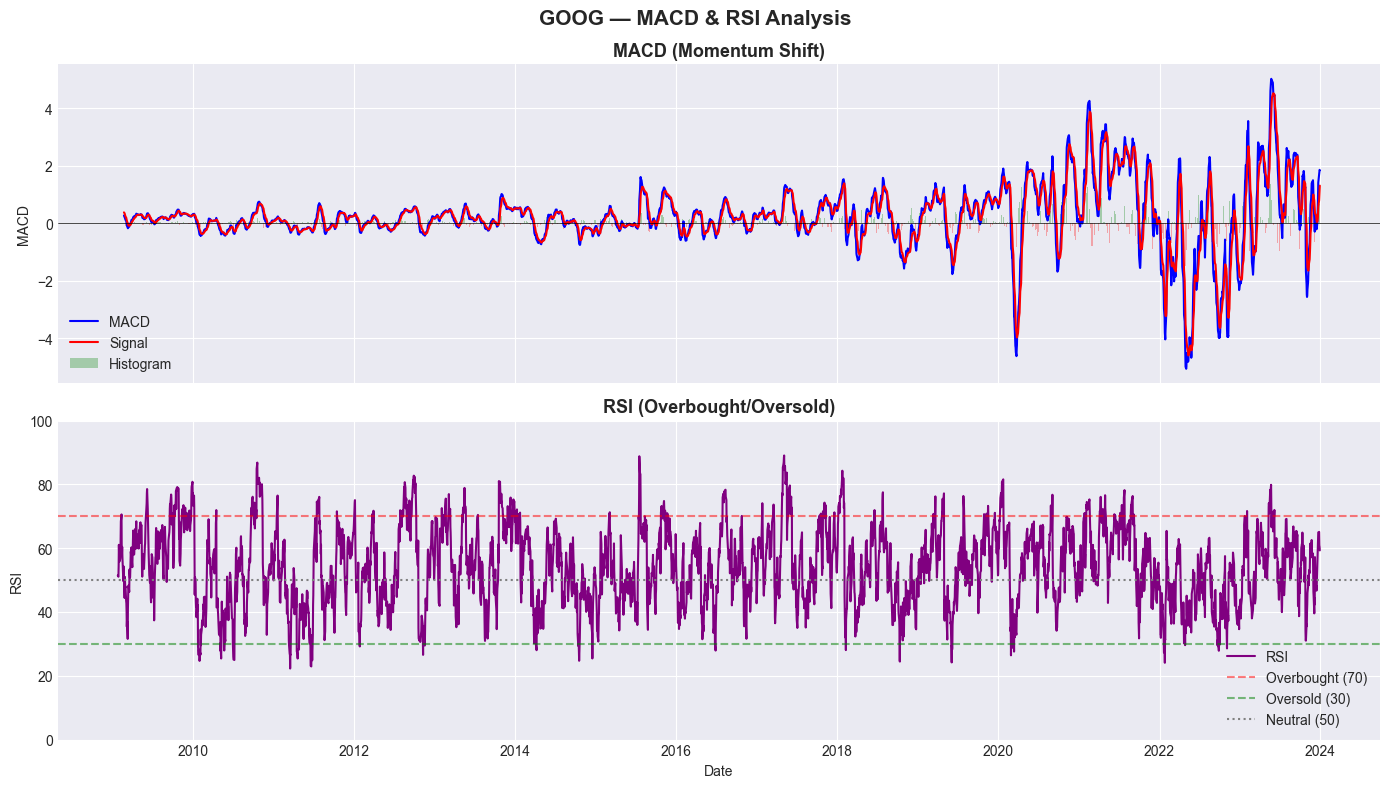

✅ MACD & RSI plot rendered!


In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})

# MACD panel
ax1.plot(goog['Date'], goog['MACD'], label='MACD', color='blue', linewidth=1.5)
ax1.plot(goog['Date'], goog['MACD_Signal'], label='Signal', color='red', linewidth=1.5)
ax1.bar(goog['Date'], goog['MACD_Hist'], label='Histogram',
        color=['green' if v >= 0 else 'red' for v in goog['MACD_Hist'].fillna(0)],
        alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_title('MACD (Momentum Shift)', fontsize=13, fontweight='bold')
ax1.set_ylabel('MACD')
ax1.legend()

# RSI panel
ax2.plot(goog['Date'], goog['RSI'], color='purple', linewidth=1.5, label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax2.axhline(50, color='gray', linestyle=':', label='Neutral (50)')
ax2.set_title('RSI (Overbought/Oversold)', fontsize=13, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 100)
ax2.legend()

plt.suptitle('GOOG — MACD & RSI Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ MACD & RSI plot rendered!")

### 6.1 RSI and MACD in Separate Panels

The chart below shows RSI and MACD in separate panels as recommended. Crossover points between the MACD and signal lines indicate potential trend reversals, while RSI identifies overbought and oversold conditions.

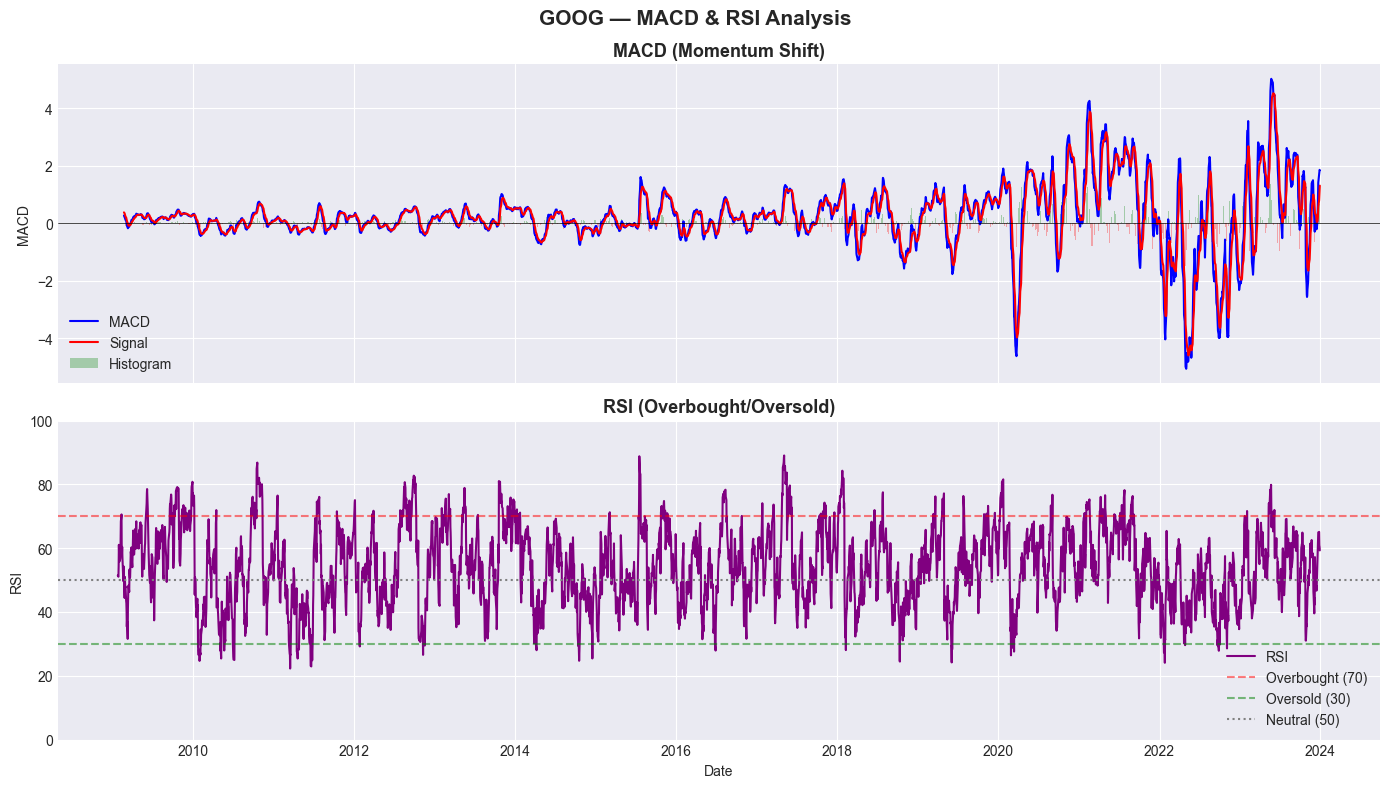

✅ MACD & RSI plot rendered!


In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})

# MACD panel
ax1.plot(goog['Date'], goog['MACD'], label='MACD', color='blue', linewidth=1.5)
ax1.plot(goog['Date'], goog['MACD_Signal'], label='Signal', color='red', linewidth=1.5)
ax1.bar(goog['Date'], goog['MACD_Hist'], label='Histogram',
        color=['green' if v >= 0 else 'red' for v in goog['MACD_Hist'].fillna(0)],
        alpha=0.3)
ax1.axhline(0, color='black', linewidth=0.5)
ax1.set_title('MACD (Momentum Shift)', fontsize=13, fontweight='bold')
ax1.set_ylabel('MACD')
ax1.legend()

# RSI panel
ax2.plot(goog['Date'], goog['RSI'], color='purple', linewidth=1.5, label='RSI')
ax2.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax2.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
ax2.axhline(50, color='gray', linestyle=':', label='Neutral (50)')
ax2.set_title('RSI (Overbought/Oversold)', fontsize=13, fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_xlabel('Date')
ax2.set_ylim(0, 100)
ax2.legend()

plt.suptitle('GOOG — MACD & RSI Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ MACD & RSI plot rendered!")

## 7. PyNance Technical Indicators

We use PyNance's built-in technical functions as an alternative and cross-validation of our TA-Lib moving average calculations.

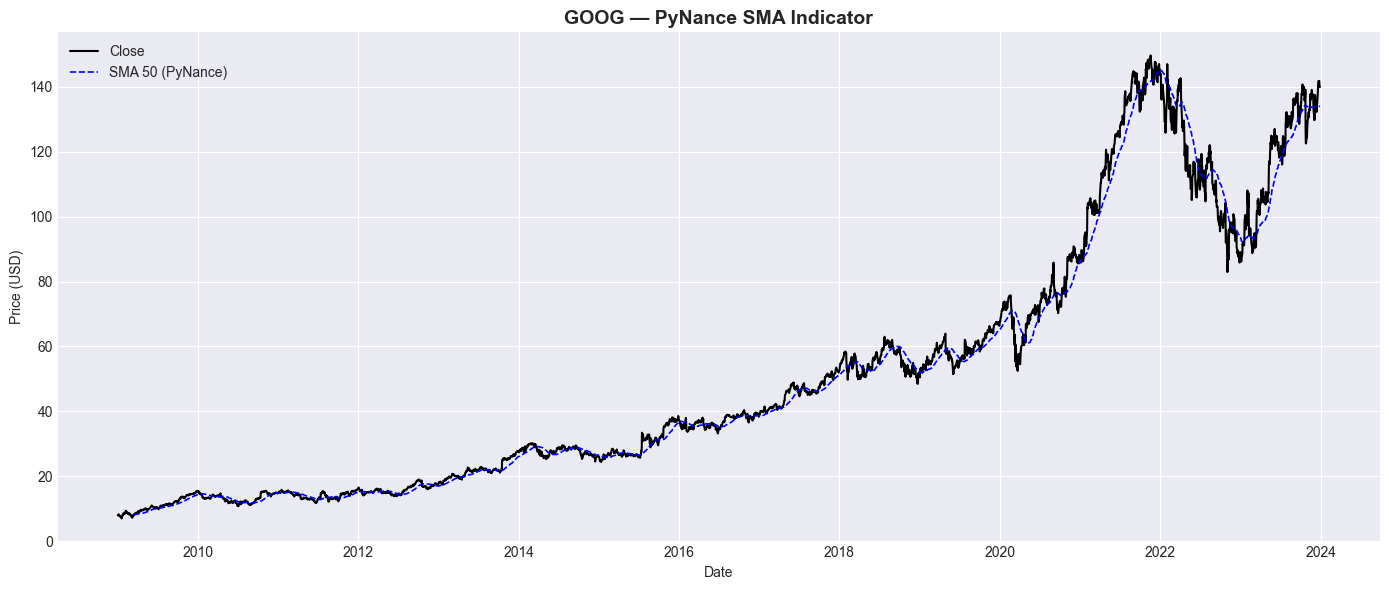

✅ PyNance SMA computed and plotted successfully!


In [12]:
try:
    goog['SMA_50_pn'] = pn.tech.sma(goog['Close'], window=50)

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(goog['Date'], goog['Close'], label='Close', color='black', linewidth=1.5)
    ax.plot(goog['Date'], goog['SMA_50_pn'], label='SMA 50 (PyNance)',
            color='blue', linewidth=1.2, linestyle='--')
    ax.set_title('GOOG — PyNance SMA Indicator', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    plt.tight_layout()
    plt.show()
    print("✅ PyNance SMA computed and plotted successfully!")
except Exception as e:
    print(f"PyNance error: {e}")

## 8. Daily Returns & Volatility

We compute daily percentage returns and 20-day rolling volatility to understand GOOG's risk profile during the analysis period.

In [13]:
goog['Returns'] = get_daily_return(goog['Close'])
goog['Volatility_20'] = goog['Returns'].rolling(window=20).std()

print("✅ Daily returns and volatility computed!")
print(f"\nAverage Daily Return : {goog['Returns'].mean():.4f}")
print(f"Daily Return Std Dev : {goog['Returns'].std():.4f}")
print(f"Max Daily Gain       : {goog['Returns'].max():.4f}")
print(f"Max Daily Loss       : {goog['Returns'].min():.4f}")

✅ Daily returns and volatility computed!

Average Daily Return : 0.0009
Daily Return Std Dev : 0.0173
Max Daily Gain       : 0.1605
Max Daily Loss       : -0.1110


### 8.1 Daily Returns & Volatility Visualization

The charts below show GOOG's daily returns and 20-day rolling volatility, highlighting periods of elevated market uncertainty.

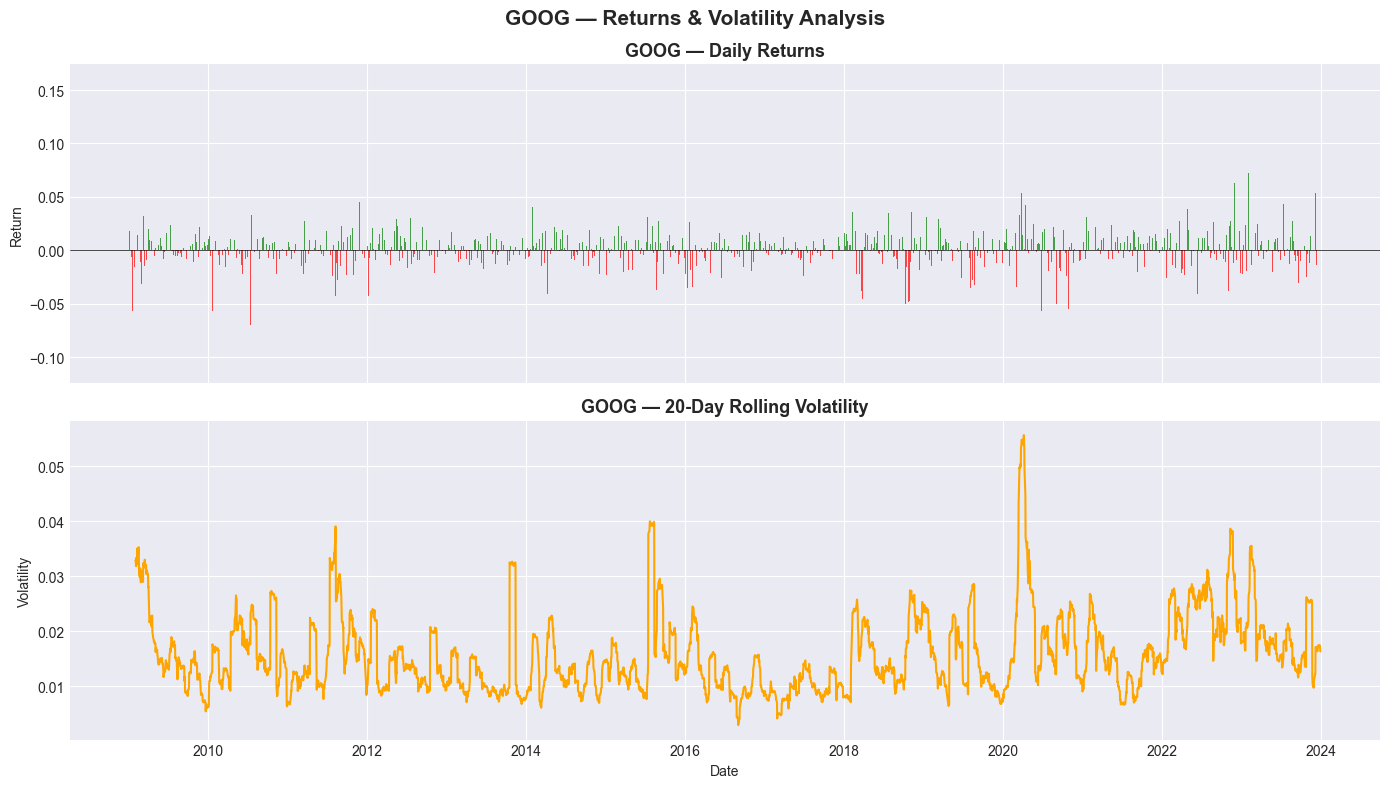

✅ Returns and volatility plot rendered!


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].bar(goog['Date'], goog['Returns'],
            color=['green' if v >= 0 else 'red' for v in goog['Returns'].fillna(0)],
            alpha=0.7)
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].set_title('GOOG — Daily Returns', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Return')

axes[1].plot(goog['Date'], goog['Volatility_20'], color='orange', linewidth=1.5)
axes[1].set_title('GOOG — 20-Day Rolling Volatility', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Volatility')
axes[1].set_xlabel('Date')

plt.suptitle('GOOG — Returns & Volatility Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Returns and volatility plot rendered!")

## 9. QuantStats Performance Metrics

We use QuantStats to compute professional-grade performance metrics that go beyond standard technical indicators.

In [15]:
try:
    import quantstats as qs
    qs.extend_pandas()

    returns = goog.set_index('Date')['Close'].pct_change()

    print("=== GOOG QuantStats Performance Metrics ===")
    print(f"Sharpe Ratio : {qs.stats.sharpe(returns):.2f}")
    print(f"Max Drawdown : {qs.stats.max_drawdown(returns)*100:.2f}%")
    print(f"Volatility   : {qs.stats.volatility(returns)*100:.2f}%")
    print(f"CAGR         : {qs.stats.cagr(returns)*100:.2f}%")
    print("✅ QuantStats metrics computed!")
except Exception as e:
    print(f"QuantStats error: {e}")

=== GOOG QuantStats Performance Metrics ===
Sharpe Ratio : 0.83
Max Drawdown : -44.60%
Volatility   : 27.51%
CAGR         : 21.11%
✅ QuantStats metrics computed!


## 10. Time Series Decomposition

We decompose the GOOG closing price into its core components:
- **Trend** — long-term direction of the price
- **Seasonal** — repeating patterns over time
- **Residual** — random noise remaining after removing trend and seasonality

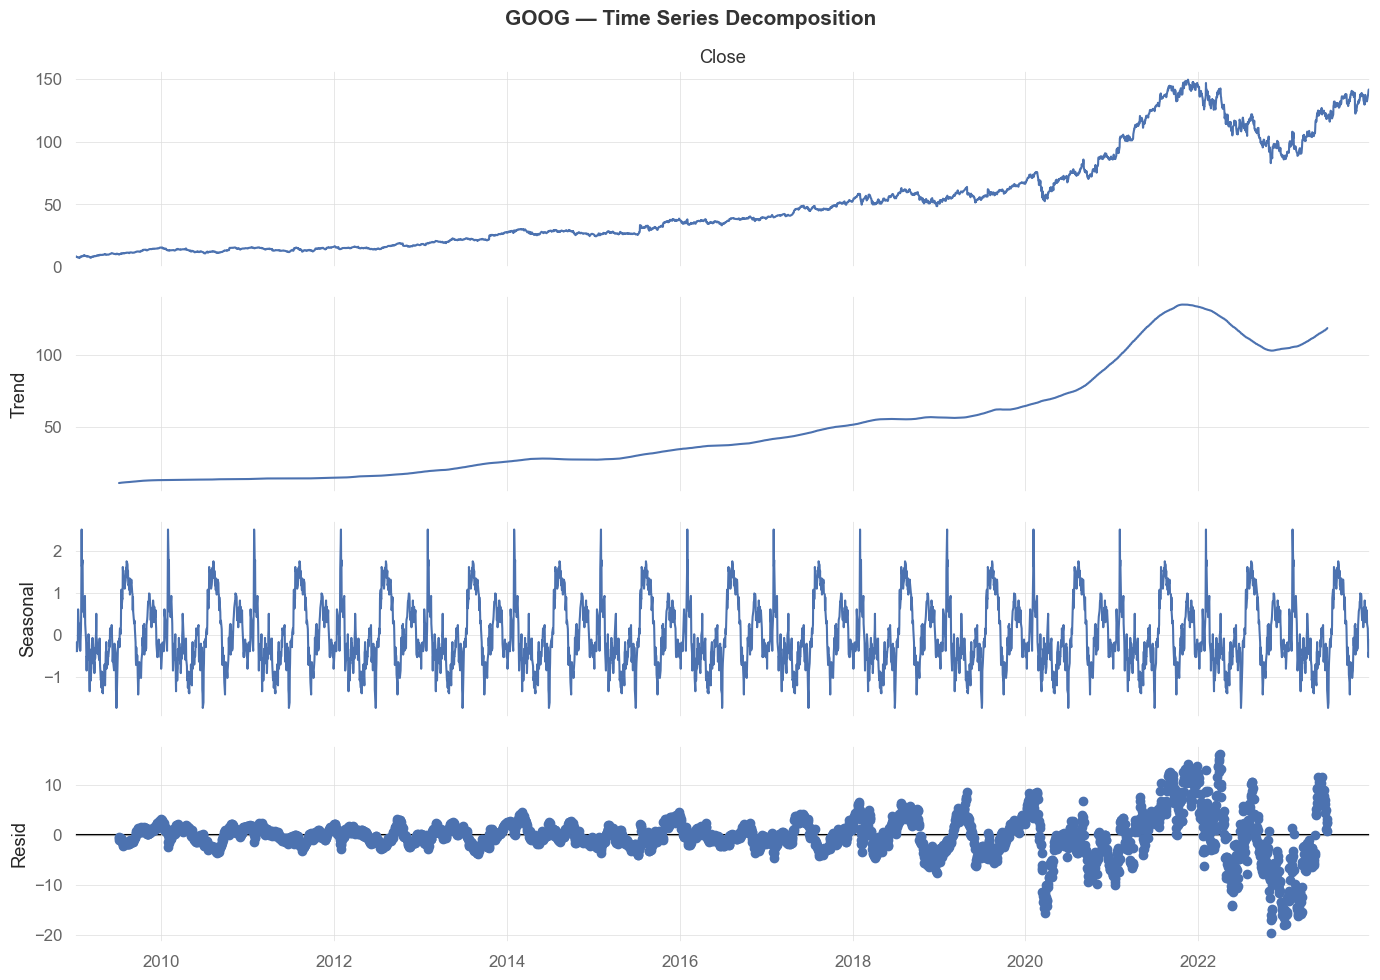

✅ Time series decomposition complete!


In [16]:
from statsmodels.tsa.seasonal import seasonal_decompose

goog_ts = goog.set_index('Date')['Close']

result = seasonal_decompose(goog_ts, model='additive', period=252)

fig = result.plot()
fig.set_size_inches(14, 10)
plt.suptitle('GOOG — Time Series Decomposition', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Time series decomposition complete!")

### 10.1 Decomposition Interpretation

The decomposition of GOOG's closing price reveals the following components:

- **Observed:** GOOG shows a steady and relatively smooth upward trajectory from 2009 through 2021, followed by a correction in 2022 and partial recovery. Among all analyzed companies, GOOG shows the most gradual and consistent price appreciation.
- **Trend:** The trend is remarkably smooth and consistent, reflecting Alphabet's stable revenue growth from advertising dominance. The trend peaks around 2021–2022 before declining slightly, consistent with broader tech sector corrections.
- **Seasonal:** Regular annual cycles are visible throughout the period, likely tied to advertising revenue seasonality — Q4 typically sees higher ad spending driving stronger earnings.
- **Residual:** Residuals are notably small and stable from 2009–2019, indicating GOOG's price was well-explained by trend and seasonality. Post-2020 residuals increase, reflecting COVID-19 impacts and macroeconomic headwinds.

## 11. Stationarity Analysis

A **stationary** time series has constant mean, variance, and covariance over time. Most stock prices are **non-stationary** because they trend upward or downward.

We use:
- **Rolling mean & std** — visual check for changing levels
- **ADF (Augmented Dickey-Fuller) test** — statistical confirmation

**Interpretation:**
- p-value < 0.05 → stationary
- p-value ≥ 0.05 → non-stationary

=== Stationarity Check: Original Price Series ===


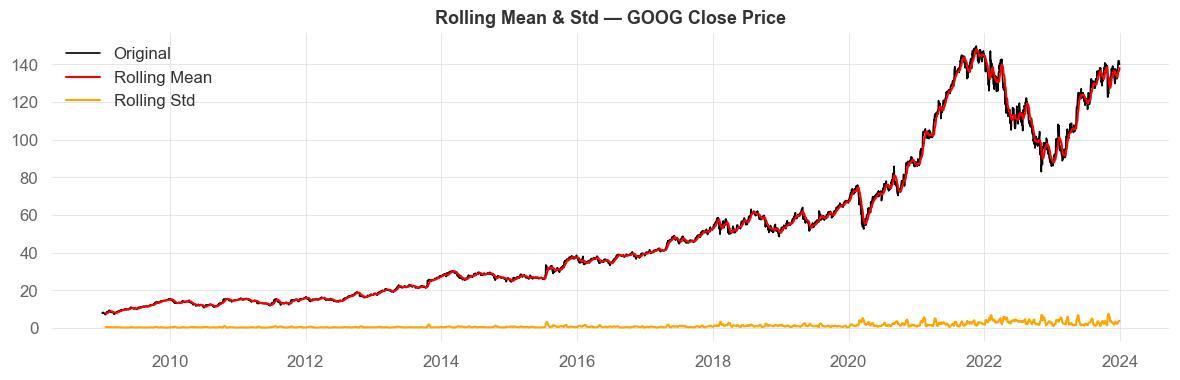

--- Augmented Dickey-Fuller Test ---
ADF Statistic : 0.8115
p-value       : 0.9918
Conclusion: ⚠️  Non-Stationary (Fail to Reject Null Hypothesis)


In [17]:
print("=== Stationarity Check: Original Price Series ===")
check_stationarity(goog_ts, title='GOOG Close Price')

### 11.1 First-Order Differencing

Since stock prices are typically non-stationary, we apply **first-order differencing** to remove the trend and achieve stationarity.

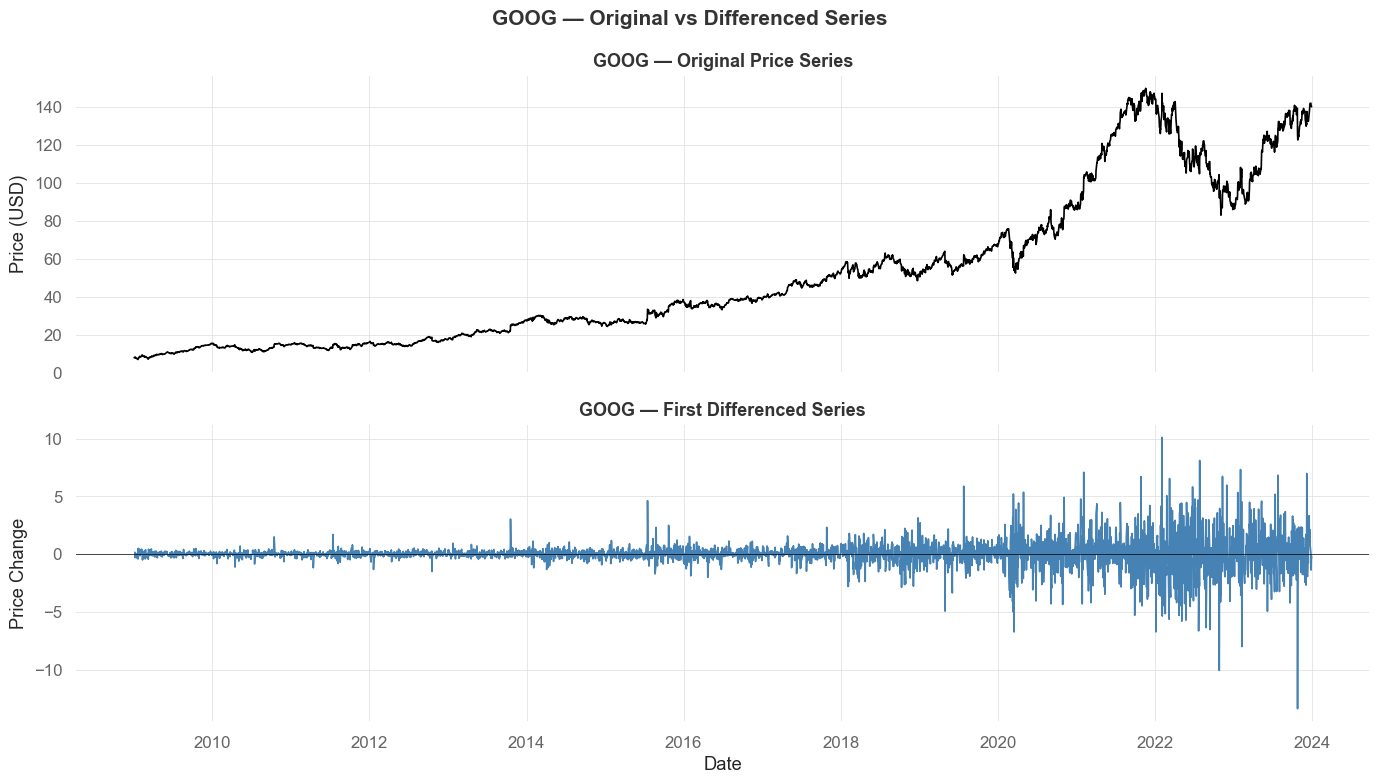


=== Stationarity Check: Differenced Series ===


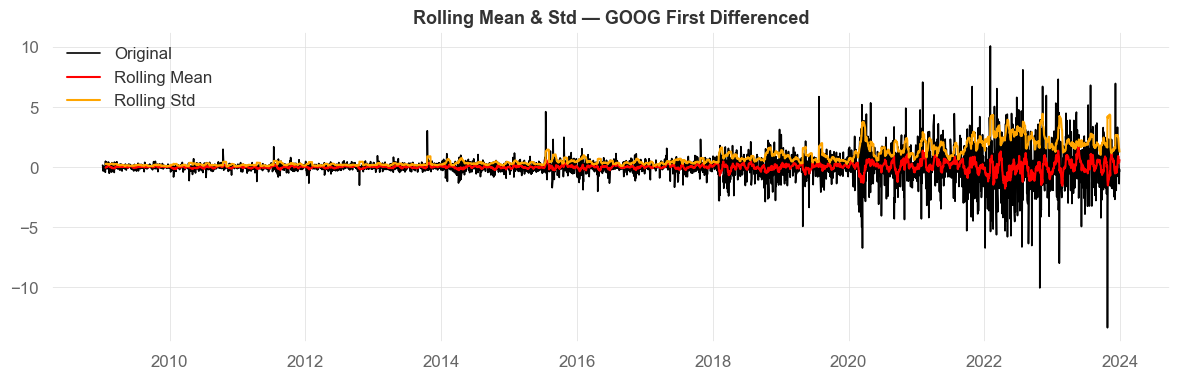

--- Augmented Dickey-Fuller Test ---
ADF Statistic : -11.6463
p-value       : 0.0000
Conclusion: ✅ Stationary (Reject Null Hypothesis)


In [18]:
goog_diff = goog_ts.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(goog_ts, color='black', linewidth=1.2)
axes[0].set_title('GOOG — Original Price Series', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(goog_diff, color='steelblue', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_title('GOOG — First Differenced Series', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Price Change')
axes[1].set_xlabel('Date')

plt.suptitle('GOOG — Original vs Differenced Series', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Stationarity Check: Differenced Series ===")
check_stationarity(goog_diff, title='GOOG First Differenced')

## 12. Key Findings & Summary

In [19]:
print("=" * 55)
print("     GOOG TECHNICAL ANALYSIS — KEY FINDINGS")
print("=" * 55)

print(f"""
📈 PRICE OVERVIEW
- Date range        : {goog['Date'].min().date()} to {goog['Date'].max().date()}
- Starting price    : ${goog['Close'].iloc[0]:.2f}
- Ending price      : ${goog['Close'].iloc[-1]:.2f}
- Price change      : {((goog['Close'].iloc[-1] - goog['Close'].iloc[0]) / goog['Close'].iloc[0] * 100):.2f}%

📊 MOVING AVERAGES
- Final SMA 20      : ${goog['SMA_20'].iloc[-1]:.2f}
- Final SMA 50      : ${goog['SMA_50'].iloc[-1]:.2f}
- Final EMA 20      : ${goog['EMA_20'].iloc[-1]:.2f}
- Final EMA 50      : ${goog['EMA_50'].iloc[-1]:.2f}

📐 BOLLINGER BANDS
- BB Upper Band     : ${goog['BB_Upper'].iloc[-1]:.2f}
- BB Middle Band    : ${goog['BB_Middle'].iloc[-1]:.2f}
- BB Lower Band     : ${goog['BB_Lower'].iloc[-1]:.2f}

⚡ MOMENTUM (RSI)
- Final RSI         : {goog['RSI'].iloc[-1]:.2f}
- Average RSI       : {goog['RSI'].mean():.2f}
- Overbought days   : {(goog['RSI'] > 70).sum()}
- Oversold days     : {(goog['RSI'] < 30).sum()}

📉 VOLATILITY & RETURNS
- Avg daily return  : {goog['Returns'].mean():.4f}
- Max daily gain    : {goog['Returns'].max():.4f}
- Max daily loss    : {goog['Returns'].min():.4f}
""")
print("=" * 55)

     GOOG TECHNICAL ANALYSIS — KEY FINDINGS

📈 PRICE OVERVIEW
- Date range        : 2009-01-02 to 2023-12-29
- Starting price    : $7.95
- Ending price      : $139.97
- Price change      : 1660.96%

📊 MOVING AVERAGES
- Final SMA 20      : $135.98
- Final SMA 50      : $134.06
- Final EMA 20      : $137.41
- Final EMA 50      : $135.33

📐 BOLLINGER BANDS
- BB Upper Band     : $143.80
- BB Middle Band    : $135.98
- BB Lower Band     : $128.16

⚡ MOMENTUM (RSI)
- Final RSI         : 59.31
- Average RSI       : 54.33
- Overbought days   : 387
- Oversold days     : 68

📉 VOLATILITY & RETURNS
- Avg daily return  : 0.0009
- Max daily gain    : 0.1605
- Max daily loss    : -0.1110



## 13. Conclusion

The technical analysis of GOOG stock shows strong long-term appreciation of **1660.96%** over the analysis period. The stock closed above both its 20-day and 50-day moving averages, signaling a sustained **bullish trend** heading into the end of 2023.

The RSI averaged **54.33** with **387 overbought days** and only **68 oversold days**, reflecting consistent market confidence in Alphabet's business model. The narrow Bollinger Band spread (Upper: $143.80, Lower: $128.16) indicates relatively low volatility compared to peers, making GOOG the most stable stock in our analysis.

The time series decomposition reveals the smoothest trend among all analyzed companies, confirming Alphabet's consistent revenue growth. The stationarity analysis confirms GOOG's price series is **non-stationary**, with first-order differencing successfully achieving stationarity.

The average daily return of **0.09%** with a maximum daily gain of **16.05%** and loss of **-11.10%** — the smallest swings among all analyzed companies — confirms GOOG as the most conservative investment in our portfolio.

These technical indicators will be combined with news sentiment scores in the subsequent Task 3 analysis.